In [72]:
import pandas as pd
import numpy as np
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error
from sklearn.model_selection import train_test_split

In [73]:
df = pd.read_csv('../data/features/features_complete.csv')

In [74]:
df.columns

Index(['Unnamed: 0', 'index', 'video_id', 'trending_date', 'title',
       'channel_title', 'category_id', 'publish_date', 'time_frame',
       'published_day_of_week', 'publish_country', 'tags', 'views', 'likes',
       'dislikes', 'comment_count', 'comments_disabled', 'ratings_disabled',
       'video_error_or_removed', 'category_name', 'is_published_weekend',
       'trending_day_of_week', 'is_trending_weekend', 'hour_of_trending',
       'days_until_trending', 'title_cleaned', 'is_english', 'title_length',
       'uppercase_words', 'contains_numbers_or_emojis', 'num_emojis',
       'has_emoji', 'emojis_list', 'sentiment_polarity',
       'sentiment_subjectivity'],
      dtype='object')

In [75]:
features = [
    'title_length', 'uppercase_words', 
    'sentiment_polarity', 'sentiment_subjectivity',
    'category_id', 
    'published_day_of_week',  
    'is_published_weekend',  
]
X = df[features]
y = np.log1p(df['views'])
print(f"Shape: X={X.shape}, y={y.shape}")

Shape: X=(26678, 7), y=(26678,)


In [76]:

X_train, X_test, y_train, y_test  = train_test_split(X,y,test_size=0.2, random_state=42)

In [77]:
# Mean Predictor Baseline Model
y_mean = y_train.mean()
y_pred = np.full(len(y_test),y_mean)
print(f"Mean Baseline Model predicts: {y_mean:,.0f} views for every video")

Mean Baseline Model predicts: 12 views for every video


In [78]:
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
mae = mean_absolute_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print(f"\nBaseline Mean Model Performance (LOG SCALE):")
print(f"RMSE: {rmse:.4f}")  # ← Changed from :.0f to :.4f
print(f"MAE:  {mae:.4f}")   # ← Changed from :.0f to :.4f
print(f"R²:   {r2:.4f}")


Baseline Mean Model Performance (LOG SCALE):
RMSE: 1.5289
MAE:  1.2308
R²:   -0.0002


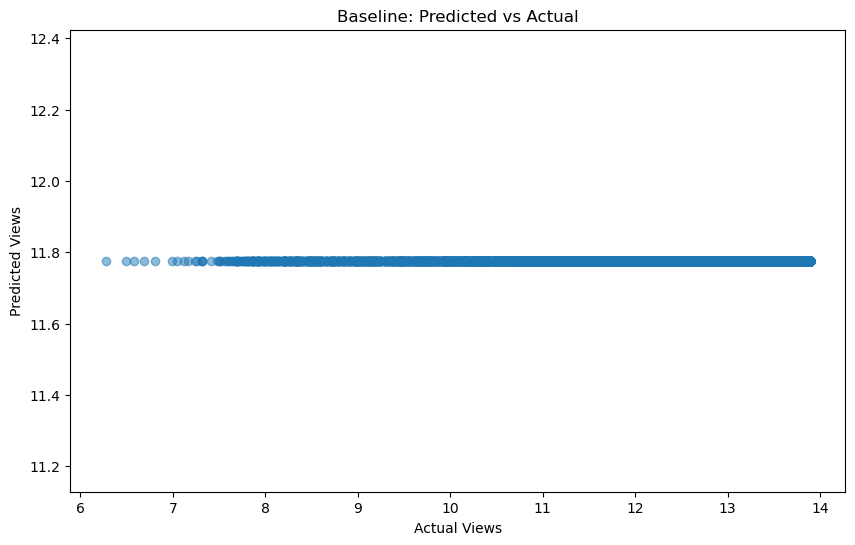

In [79]:
import matplotlib.pyplot as plt

# Scatter plot
plt.figure(figsize=(10, 6))
plt.scatter(y_test, y_pred, alpha=0.5)
plt.xlabel('Actual Views')
plt.ylabel('Predicted Views')
plt.title('Baseline: Predicted vs Actual')
plt.savefig('../reports/baseline_model/baseline_predictions.png')
plt.show()